# 04 - Baselines e XGBoost

**Objetivo:** responder se um modelo sofisticado realmente melhora em relacao a regras simples.

Comparamos:
- persistencia;
- tendencia recente;
- Ridge;
- XGBoost.

### Saidas
- metricas em CSV/HTML;
- grafico de RMSE por horizonte;
- modelos salvos em `models/`.

In [10]:
from pathlib import Path
import re
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------------
# Localiza a raiz do projeto e o dataset de forma robusta.
# Funciona se o notebook estiver em Field-Project/notebooks.
# ------------------------------------------------------------------
CWD = Path.cwd().resolve()
ROOT = CWD.parent if CWD.name.lower() == "notebooks" else CWD

RAW_PARENT = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
MODELS = ROOT / "models"

OUTPUTS = ROOT / "outputs"
FIGURES = OUTPUTS / "figures"
TABLES = OUTPUTS / "tables"
PREDICTIONS = OUTPUTS / "predictions"

for p in [INTERIM, PROCESSED, MODELS, FIGURES, TABLES, PREDICTIONS]:
    p.mkdir(parents=True, exist_ok=True)

def find_dataset_root(raw_parent: Path) -> Path:
    """Procura uma pasta que contenha Data/SHP e Data/Telemetric_Time_Series."""
    candidates = [raw_parent] + [p for p in raw_parent.rglob("*") if p.is_dir()]
    for p in candidates:
        data = p / "Data"
        if (data / "SHP").exists() and (data / "Telemetric_Time_Series").exists():
            return p
    raise FileNotFoundError(
        "Nao encontrei o dataset. Extraia o .rar dentro de data/raw/ "
        "mantendo a pasta Data/ com SHP/, Radar/ e Telemetric_Time_Series/."
    )

RAW = find_dataset_root(RAW_PARENT)
DATA = RAW / "Data"
SHP = DATA / "SHP"
TELE = DATA / "Telemetric_Time_Series"
RADAR = DATA / "Radar"

print("ROOT:", ROOT)
print("Dataset:", RAW)

ROOT: C:\Users\osmar\Área de Trabalho\Field-Project
Dataset: C:\Users\osmar\Área de Trabalho\Field-Project\data\raw\TTI-HydroMet_Dataset_version2


In [11]:
def save_table(df, stem, preview_rows=15, sort_by=None, ascending=True):
    """
    Salva a tabela completa em CSV e HTML e mostra apenas uma amostra no notebook.
    Isso evita outputs gigantes e facilita abrir a tabela fora do Jupyter.
    """
    z = df.copy()
    if sort_by is not None and sort_by in z.columns:
        z = z.sort_values(sort_by, ascending=ascending)

    csv_path = TABLES / f"{stem}.csv"
    html_path = TABLES / f"{stem}.html"

    z.to_csv(csv_path, index=False)
    z.to_html(html_path, index=False)

    display(Markdown(
        f"**Tabela completa salva em:**  \n"
        f"- `{csv_path.relative_to(ROOT)}`  \n"
        f"- `{html_path.relative_to(ROOT)}`  \n"
        f"Mostrando apenas as primeiras {min(preview_rows, len(z))} linhas:"
    ))
    display(z.head(preview_rows))
    return z

def save_figure(fig, stem, dpi=220):
    """Salva uma figura em PNG e a mantem visivel no notebook."""
    path = FIGURES / f"{stem}.png"
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    display(Markdown(f"**Figura salva em:** `{path.relative_to(ROOT)}`"))
    return path

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import joblib

QUICK_RUN = False  # True apenas para testar o pipeline mais rapidamente.

x = pd.read_parquet(PROCESSED / "features_causal.parquet")

feature_cols = [c for c in x.columns if c != "split" and not c.startswith("target_")]
stage_cols = [c for c in feature_cols if c.startswith("stage_")]
rain_cols = [c for c in feature_cols if c.startswith("rain_")]
up_cols = [c for c in feature_cols if c.startswith("up_")]

groups = pd.DataFrame({
    "grupo": ["nivel_413", "chuva", "montante", "total"],
    "n_features": [len(stage_cols), len(rain_cols), len(up_cols), len(feature_cols)],
})
display(groups)

,grupo,n_features
0,nivel_413,22
1,chuva,123
2,montante,21
3,total,166


In [13]:
def get_split(df, horizon, split_name):
    target = f"target_delta_{horizon}m"
    z = df[df["split"] == split_name].copy()
    z = z[z["stage_now"].notna() & z[target].notna()]
    if QUICK_RUN and split_name == "train":
        z = z.iloc[::2].copy()
    return z, target

def regression_metrics(y_delta, pred_delta, stage_now):
    y_delta = np.asarray(y_delta)
    pred_delta = np.asarray(pred_delta)
    stage_now = np.asarray(stage_now)
    true_stage = stage_now + y_delta
    pred_stage = stage_now + pred_delta
    return {
        "MAE_m": mean_absolute_error(y_delta, pred_delta),
        "RMSE_m": mean_squared_error(y_delta, pred_delta) ** 0.5,
        "R2_stage": r2_score(true_stage, pred_stage),
    }

In [14]:
results = {}

for horizon in [60, 120, 240]:
    valid, target = get_split(x, horizon, "validation")

    pred_persistence = np.zeros(len(valid), dtype="float32")
    results[(horizon, "persistence")] = regression_metrics(
        valid[target], pred_persistence, valid["stage_now"]
    )

    pred_trend = (
        valid["stage_change_1h"].fillna(0).to_numpy() * (horizon / 60)
    )
    results[(horizon, "trend")] = regression_metrics(
        valid[target], pred_trend, valid["stage_now"]
    )

In [15]:
compact_rain = [
    c for c in feature_cols
    if c.startswith("rain_basin_") or c.startswith("rain_gauges_")
]
ridge_features = stage_cols + compact_rain

for horizon in [60, 120, 240]:
    train, target = get_split(x, horizon, "train")
    valid, _ = get_split(x, horizon, "validation")

    ridge = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        Ridge(alpha=10.0),
    )
    ridge.fit(train[ridge_features], train[target])
    pred = ridge.predict(valid[ridge_features])

    results[(horizon, "ridge")] = regression_metrics(
        valid[target], pred, valid["stage_now"]
    )
    joblib.dump(ridge, MODELS / f"ridge_dev_{horizon}m.joblib")

In [16]:
xgb_models = {}
best_iterations = {}

for horizon in [60, 120, 240]:
    train, target = get_split(x, horizon, "train")
    valid, _ = get_split(x, horizon, "validation")

    model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        n_estimators=250 if QUICK_RUN else 1000,
        learning_rate=0.05 if QUICK_RUN else 0.035,
        max_depth=6,
        min_child_weight=20,
        subsample=0.85,
        colsample_bytree=0.80,
        reg_lambda=5.0,
        max_bin=128,
        n_jobs=-1,
        random_state=42,
        early_stopping_rounds=40 if QUICK_RUN else 60,
    )

    model.fit(
        train[feature_cols],
        train[target],
        eval_set=[(valid[feature_cols], valid[target])],
        verbose=False,
    )

    pred = model.predict(valid[feature_cols])
    results[(horizon, "xgb")] = regression_metrics(
        valid[target], pred, valid["stage_now"]
    )

    best_iterations[horizon] = int(model.best_iteration)
    model.save_model(MODELS / f"xgb_dev_{horizon}m.json")

**Tabela completa salva em:**  
- `outputs\tables\validation_metrics.csv`  
- `outputs\tables\validation_metrics.html`  
Mostrando apenas as primeiras 12 linhas:

,horizon_min,model,MAE_m,RMSE_m,R2_stage,MAE_cm,RMSE_cm
9,60,xgb,0.036295,0.119341,0.976112,3.629528,11.934069
6,60,ridge,0.063974,0.172110,0.950315,6.397436,17.211049
0,60,persistence,0.085994,0.270306,0.877448,8.599389,27.030581
1,60,trend,0.078223,0.305061,0.843907,7.822262,30.506142
10,120,xgb,0.076453,0.252835,0.892812,7.645298,25.283505
7,120,ridge,0.113631,0.290332,0.858661,11.363092,29.033170
2,120,persistence,0.160091,0.446380,0.665895,16.009101,44.637989
3,120,trend,0.173567,0.615556,0.364658,17.356665,61.555557
11,240,xgb,0.173594,0.486108,0.603981,17.359437,48.610797
8,240,ridge,0.202664,0.514890,0.555696,20.266406,51.489009


**Figura salva em:** `outputs\figures\validation_rmse_horizons.png`

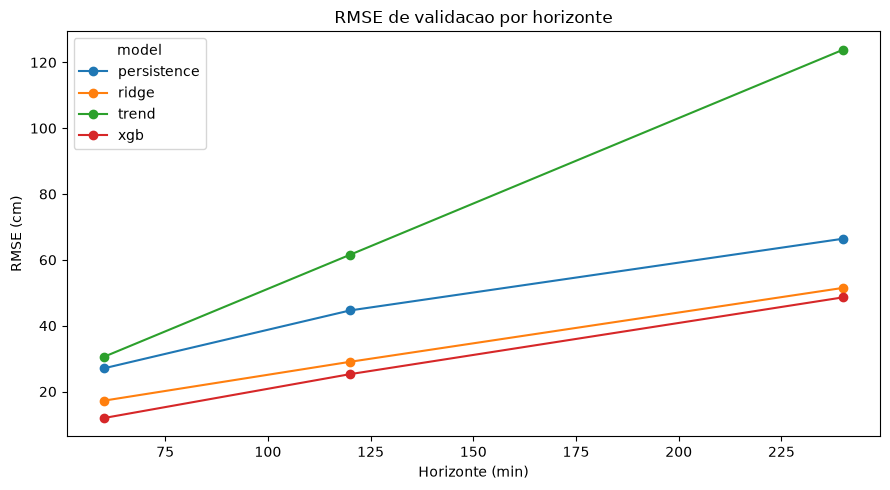

In [17]:
validation_results = pd.DataFrame(results).T.reset_index()
validation_results.columns = [
    "horizon_min", "model", "MAE_m", "RMSE_m", "R2_stage"
]
validation_results["MAE_cm"] = 100 * validation_results["MAE_m"]
validation_results["RMSE_cm"] = 100 * validation_results["RMSE_m"]

save_table(
    validation_results.sort_values(["horizon_min", "RMSE_m"]),
    "validation_metrics",
    preview_rows=20
)

pivot = validation_results.pivot(index="horizon_min", columns="model", values="RMSE_cm")
fig, ax = plt.subplots(figsize=(9, 5))
pivot.plot(marker="o", ax=ax)
ax.set_ylabel("RMSE (cm)")
ax.set_xlabel("Horizonte (min)")
ax.set_title("RMSE de validacao por horizonte")
plt.tight_layout()
save_figure(fig, "validation_rmse_horizons")
plt.show()

In [18]:
metadata = {
    "features": feature_cols,
    "ridge_features": ridge_features,
    "horizons": [60, 120, 240],
    "best_iterations": {str(k): v for k, v in best_iterations.items()},
    "train_start": "2015-04-02 00:00",
    "train_end": "2022-12-31 19:50",
    "validation_start": "2023-01-01 00:00",
    "validation_end": "2023-12-31 19:50",
}
with open(MODELS / "feature_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("Metadados salvos.")

Metadados salvos.
